# 실습 1 · 캘리브레이션 조건 비교 실험
**촬영 설계가 결과를 바꾸는가 — A/B/C 직접 검증**

| 파트 | 내용 |
|---|---|
| 01 | 실험 개요와 개념 리캡 · 환경 준비 |
| 02 | 세트별 캘리브레이션 실행 (Step 1–3) |
| 03 | 결과 비교와 해석 (비교 1–4) |
| 04 | 워핑 원리 데모와 랩업 |

**오늘의 가설 (이론 2의 주장)**
- **가설 1** — 정면·거리 고정 촬영(세트 A) → 잔차는 낮아도 f가 크게 틀린다 (f–Z 모호성)
- **가설 2** — 중앙 관측만(세트 B) → 왜곡 고차항이 폭주해 가장자리가 붕괴한다 (외삽)

데이터는 실제 AVM 리그의 **front_right 어안 카메라** ChArUco 촬영본이며, 렌즈가 어안이므로
모델은 `cv2.fisheye`(equidistant, k₁–k₄)를 사용합니다. 파라미터 표준편차 σ는 이론 2의 핵심식
**Σ ≈ σ²(JᵀJ)⁻¹** 을 수치 야코비안으로 **직접 구현**해 계산합니다.

In [1]:
# ── 셀 1 · 환경 준비 ──────────────────────────────────────────── [체크 17:10]
import cv2, json, math, time, os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 한글 폰트 (설치된 것 자동 선택)
import matplotlib.font_manager as fm
for cand in ['Malgun Gothic', 'AppleGothic', 'NanumGothic',
             'Noto Sans CJK KR', 'Noto Sans CJK JP', 'Noto Sans KR']:
    if any(cand == f.name for f in fm.fontManager.ttflist):
        plt.rcParams['font.family'] = cand
        break
plt.rcParams['axes.unicode_minus'] = False

BASE = Path('.')
DATA = BASE / 'lab1_data'
OUT  = BASE / 'out';  OUT.mkdir(exist_ok=True)
CACHE = BASE / 'det_cache'; CACHE.mkdir(exist_ok=True)

SETS = {'setA': '정면·거리 고정 (10장)',
        'setB': '중앙 관측만 (15장)',
        'setC': '권장 · 다양 (15장)',
        'master': '마스터 (60장)'}

print('OpenCV', cv2.__version__, '(aruco 필요: opencv-python ≥ 4.7)')
for s, desc in SETS.items():
    n = len(list((DATA / s).glob('*.jpg')))
    print(f'  {s:7s} {n:3d}장 — {desc}')
# ※ 저사양 노트북: 아래 주석 해제 시 검출 단계에서 1/2 크기로 처리 (정밀도 소폭 하락)
# DOWNSCALE = 0.5
DOWNSCALE = 1.0

OpenCV 4.10.0 (aruco 필요: opencv-python ≥ 4.7)
  setA     10장 — 정면·거리 고정 (10장)
  setB     15장 — 중앙 관측만 (15장)
  setC     15장 — 권장 · 다양 (15장)
  master   60장 — 마스터 (60장)


---
## Part 1 · 보드와 세트 확인

이번 실습의 타깃은 **ChArUco 보드 (8×7 squares, DICT_5X5)** — 체커보드에 ArUco 마커를 심은 보드입니다.

체커보드 대비 장점 두 가지가 오늘 데이터에 꼭 필요합니다.
1. **부분 검출 허용** — 보드가 화면 밖으로 잘려도 보이는 코너만으로 사용 가능
2. **코너마다 ID** — 어느 코너인지 자동 식별 → 대응 관계가 항상 정확

> 코너 위치는 마커 기반으로 자동 정밀 산출됩니다.

In [2]:
# ── 셀 2 · 보드 정의 ────────────────────────────────────────────
binfo = json.load(open(BASE / 'board.json', encoding='utf-8'))
ARUCO = cv2.aruco.getPredefinedDictionary(getattr(cv2.aruco, binfo['aruco_dict']))
BOARD = cv2.aruco.CharucoBoard((binfo['squares_x'], binfo['squares_y']),
                               binfo['square_size'], binfo['marker_size'], ARUCO)
DET = cv2.aruco.CharucoDetector(BOARD)
OBJ = BOARD.getChessboardCorners()          # (42, 3) 내부 코너의 보드 좌표
W, H = binfo['image_size']
CTR = np.array([W/2, H/2]); HALF_DIAG = math.hypot(*CTR)
print(f"ChArUco {binfo['squares_x']}x{binfo['squares_y']} → 내부 코너 {len(OBJ)}개, 영상 {W}x{H}")
print('비고:', binfo['size_note'])

ChArUco 8x7 → 내부 코너 42개, 영상 1920x1200
비고: 실측 치수 아님 — 비율(0.75)만 의미. 내부 파라미터는 보드 스케일과 무관.


---
## Part 2 · 세트별 캘리브레이션 실행
### Step 1 — ChArUco 검출 (+캐시)

`CharucoDetector.detectBoard` 한 번이면 마커 탐지 → 코너 보간 → ID 부여까지 끝납니다.
같은 세트를 다시 돌릴 때를 위해 결과를 `det_cache/`에 저장합니다.

setA    검출 10/10장, 코너/장 중앙값 42 (최소 42)
setB    검출 15/15장, 코너/장 중앙값 42 (최소 42)
setC    검출 15/15장, 코너/장 중앙값 42 (최소 24)
master  검출 60/60장, 코너/장 중앙값 39 (최소 24)
검출 소요 0s


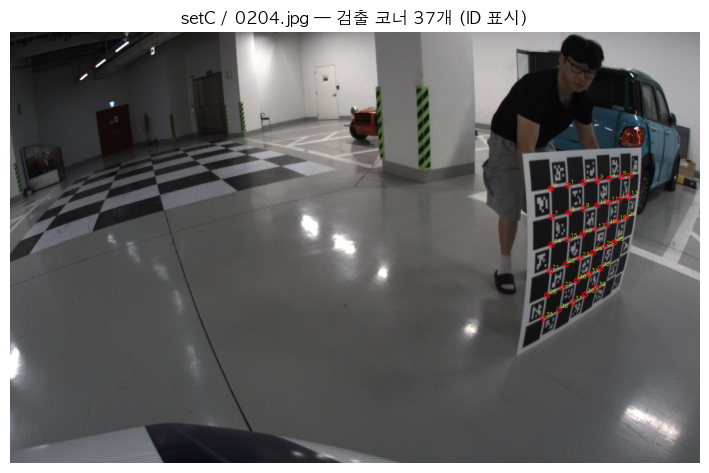

In [3]:
# ── 셀 3 · Step 1: 검출 함수 + 전 세트 실행 ───────────────────── [체크 17:18]
def _pack(arrs):
    """'배열의 리스트' 구조를 보존하는 object 배열.
    np.array(리스트, dtype=object)는 원소 길이가 모두 같으면 2D로 뭉개지고
    dtype까지 object가 되어(int64→object) 캐시를 다시 읽을 때 색인·norm이 깨진다."""
    a = np.empty(len(arrs), dtype=object)
    for i, v in enumerate(arrs):
        a[i] = v
    return a

def detect_folder(set_name, min_corners=8):
    npz = CACHE / f'{set_name}.npz'
    if npz.exists():
        z = np.load(npz, allow_pickle=True)
        # 캐시는 dtype·형상을 명시 복원 (예전 형식으로 저장된 캐시도 함께 교정됨)
        return ([str(n) for n in z['names']],
                [np.asarray(i, dtype=int).ravel() for i in z['ids']],
                [np.asarray(p, dtype=np.float64).reshape(-1, 2) for p in z['pts']])
    names, ids_l, pts_l = [], [], []
    for f in sorted((DATA / set_name).glob('*.jpg')):
        g = cv2.imread(str(f), cv2.IMREAD_GRAYSCALE)
        if DOWNSCALE != 1.0:
            g = cv2.resize(g, None, fx=DOWNSCALE, fy=DOWNSCALE)
        ch_c, ch_ids, _, _ = DET.detectBoard(g)
        if ch_ids is None or len(ch_ids) < min_corners:
            continue
        names.append(f.name)
        ids_l.append(ch_ids.ravel().astype(int))
        pts_l.append(ch_c.reshape(-1, 2).astype(np.float64) / DOWNSCALE)
    np.savez_compressed(npz, names=_pack(names), ids=_pack(ids_l), pts=_pack(pts_l))
    return names, ids_l, pts_l

t0 = time.time()
DETS = {s: detect_folder(s) for s in SETS}
for s in SETS:
    names, ids_l, _ = DETS[s]
    total = len(list((DATA / s).glob('*.jpg')))
    ncor = [len(i) for i in ids_l]
    print(f'{s:7s} 검출 {len(names)}/{total}장, 코너/장 중앙값 {int(np.median(ncor))} (최소 {min(ncor)})')
print(f'검출 소요 {time.time()-t0:.0f}s')

# 검출 오버레이 예시 1장
name0, ids0, pts0 = DETS['setC'][0][0], DETS['setC'][1][0], DETS['setC'][2][0]
vis = cv2.imread(str(DATA / 'setC' / name0))
for (x, y), i in zip(pts0.astype(int), ids0):
    cv2.circle(vis, (int(x), int(y)), 7, (0, 0, 255), 2)
    cv2.putText(vis, str(i), (int(x) + 6, int(y) - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)
plt.figure(figsize=(9, 5.6)); plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f'setC / {name0} — 검출 코너 {len(ids0)}개 (ID 표시)'); plt.axis('off'); plt.show()

### Step 2 — 어안 캘리브레이션 + σ 직접 계산

표준 렌즈였다면 `calibrateCameraExtended`가 σ를 공짜로 주지만, **어안 API에는 Extended가 없습니다.**
그래서 이론 2의 핵심식을 우리가 구현합니다.

$$\Sigma_\theta \;\approx\; \sigma^2 \,(J^\top J)^{-1}$$

- 파라미터: 내부 8개 `[fx, fy, cx, cy, k1..k4]` + 뷰마다 자세 6개
- $J$: `cv2.fisheye.projectPoints`를 파라미터별로 미세 변화시키는 **수치 미분**
- $\sigma^2$: 잔차제곱합 / 자유도

> 촬영 배치가 $J$를 만들고, $J$가 σ를 결정한다 — 오늘 이 문장을 숫자로 확인합니다.

In [4]:
# ── 셀 4 · Step 2: 캘리브레이션·σ 함수 정의 ─────────────────────
FLAGS = cv2.fisheye.CALIB_RECOMPUTE_EXTRINSIC | cv2.fisheye.CALIB_FIX_SKEW

def calibrate_fisheye(ops, ips):
    K = np.zeros((3, 3)); D = np.zeros((4, 1))
    rms, K, D, rv, tv = cv2.fisheye.calibrate(
        [o.reshape(1, -1, 3).astype(np.float64) for o in ops],
        [i.reshape(1, -1, 2).astype(np.float64) for i in ips],
        (W, H), K, D, flags=FLAGS)
    return rms, K, D.ravel(), rv, tv

def sigma_intrinsics(ops, ips, K, D, rv, tv):
    """Σ ≈ σ²(JᵀJ)⁻¹ 를 수치 야코비안으로 직접 계산 → 내부 8개의 σ 반환"""
    th0 = np.r_[K[0, 0], K[1, 1], K[0, 2], K[1, 2], D]
    def proj(th, j, rvj=None, tvj=None):
        Kj = np.array([[th[0], 0, th[2]], [0, th[1], th[3]], [0, 0, 1]])
        p, _ = cv2.fisheye.projectPoints(ops[j].reshape(1, -1, 3),
                                         rv[j] if rvj is None else rvj,
                                         tv[j] if tvj is None else tvj,
                                         Kj, th[4:8].reshape(4, 1))
        return p.reshape(-1, 2)
    res = np.concatenate([(proj(th0, j) - ips[j].reshape(-1, 2)).ravel()
                          for j in range(len(ops))])
    V, nI = len(ops), 8
    J = np.zeros((res.size, nI + 6 * V)); r0 = 0
    for j in range(V):
        nr = len(ops[j]) * 2; base = proj(th0, j)
        for a in range(nI):                     # 내부 파라미터 열
            e = th0.copy(); h = max(1e-6, 1e-6 * abs(th0[a])); e[a] += h
            J[r0:r0 + nr, a] = (proj(e, j) - base).ravel() / h
        for b in range(6):                      # 뷰 j의 자세 열
            h = 1e-6
            if b < 3:
                rvj = rv[j].copy(); rvj.ravel()[b] += h
                p2 = proj(th0, j, rvj=rvj)
            else:
                tvj = tv[j].copy(); tvj.ravel()[b - 3] += h
                p2 = proj(th0, j, tvj=tvj)
            J[r0:r0 + nr, nI + 6 * j + b] = (p2 - base).ravel() / h
        r0 += nr
    dof = res.size - J.shape[1]
    s2 = (res @ res) / dof
    cov = s2 * np.linalg.pinv(J.T @ J)
    names = ['fx', 'fy', 'cx', 'cy', 'k1', 'k2', 'k3', 'k4']
    return dict(zip(names, np.sqrt(np.diag(cov)[:nI])))

def run_calib(set_name, central_mask=None, min_corners=10):
    """central_mask: 중심 반경 비율(예: 0.6) — 그 밖의 코너 관측을 버림 (세트 B 전용)"""
    _, ids_l, pts_l = DETS[set_name]
    ops, ips = [], []
    for ids, pts in zip(ids_l, pts_l):
        m = np.ones(len(ids), bool)
        if central_mask is not None:
            m = np.linalg.norm(pts - CTR, axis=1) < central_mask * HALF_DIAG
        if m.sum() < min_corners:
            continue
        ops.append(OBJ[ids[m]].copy()); ips.append(pts[m].copy())
    rms, K, D, rv, tv = calibrate_fisheye(ops, ips)
    sig = sigma_intrinsics(ops, ips, K, D, rv, tv)
    # rvecs/tvecs = 뷰별 외부 파라미터 — 셀 7-b의 extrinsic 시각화에서 사용
    return dict(set=set_name, n_img=len(ops), rms=rms, K=K, D=D, sigma=sig,
                rvecs=rv, tvecs=tv, central_mask=central_mask)
print('함수 준비 완료 — run_calib() 사용')

함수 준비 완료 — run_calib() 사용


### Step 3 — 세 세트 일괄 실행과 기록 시트

**모델 통일 원칙**: 전 세트 동일한 어안 4계수 모델·동일 플래그 — 바꾸면 실험 무효.

세트 B는 파일이 아니라 **관측을 통제**합니다: 같은 화각의 영상에서 *중심 반경 0.6 이내* 코너만
사용해 "중앙만 찍은 촬영"을 재현합니다 (`central_mask=0.6`). 위반 변인이 커버리지 하나로 깔끔히 고정됩니다.

In [5]:
# ── 셀 5 · Step 3: 일괄 실행 → 기록 시트 ───────────────────────── [체크 17:35]
t0 = time.time()
RES = {
    'A': run_calib('setA'),
    'B': run_calib('setB', central_mask=0.6),
    'C': run_calib('setC'),
    'D': run_calib('master'),
}
REF = json.load(open(BASE / 'reference' / 'master_params.json', encoding='utf-8'))
fx_ref = REF['K'][0][0]
print(f'일괄 실행 {time.time()-t0:.0f}s  ·  참조 fx = {fx_ref:.1f} (233장, rms {REF["rms_px"]:.2f}px)')

import pandas as pd
rows = []
for k in 'ABCD':
    r = RES[k]
    rows.append({
        '세트': k, '장수': r['n_img'], 'RMS[px]': round(r['rms'], 3),
        'fx[px]': round(r['K'][0, 0], 1),
        'Δfx/fx_ref[%]': round((r['K'][0, 0] - fx_ref) / fx_ref * 100, 2),
        'σ(fx)': round(r['sigma']['fx'], 2),
        'k3': round(r['D'][2], 3), 'σ(k3)': round(r['sigma']['k3'], 4),
        'k4': round(r['D'][3], 3), 'σ(k4)': round(r['sigma']['k4'], 4),
        '가장자리(육안)': '',
    })
rows.append({'세트': '참조', '장수': REF['n_images'], 'RMS[px]': round(REF['rms_px'], 3),
             'fx[px]': round(fx_ref, 1), 'Δfx/fx_ref[%]': 0.0,
             'σ(fx)': round(REF['sigma']['fx'], 2),
             'k3': round(REF['D'][2], 3), 'σ(k3)': round(REF['sigma']['k3'], 4),
             'k4': round(REF['D'][3], 3), 'σ(k4)': round(REF['sigma']['k4'], 4),
             '가장자리(육안)': '—'})
SHEET = pd.DataFrame(rows)
SHEET.to_csv(OUT / 'record_sheet.csv', index=False, encoding='utf-8-sig')
SHEET

일괄 실행 1s  ·  참조 fx = 1048.5 (233장, rms 1.40px)


,세트,장수,RMS[px],fx[px],Δfx/fx_ref[%],σ(fx),k3,σ(k3),k4,σ(k4),가장자리(육안)
0,A,10,0.688,956.6,-8.77,0.50,-0.084,0.0012,-0.008,0.0016,
1,B,15,1.098,1004.8,-4.17,0.63,2.005,0.0040,-1.931,0.0066,
2,C,15,1.327,1022.1,-2.52,0.96,-0.006,0.0014,0.010,0.0010,
3,D,60,1.598,1041.2,-0.70,0.57,-0.102,0.0008,0.040,0.0006,
4,참조,233,1.401,1048.5,0.00,0.27,-0.104,0.0004,0.041,0.0003,—


---
## Part 3 · 결과 비교와 해석
### 비교 1·2 — f는 틀리는데 RMS는 낮다?

아래 세 지표를 **나란히** 보세요. 순위가 서로 어떻게 어긋나는지가 오늘의 핵심입니다.

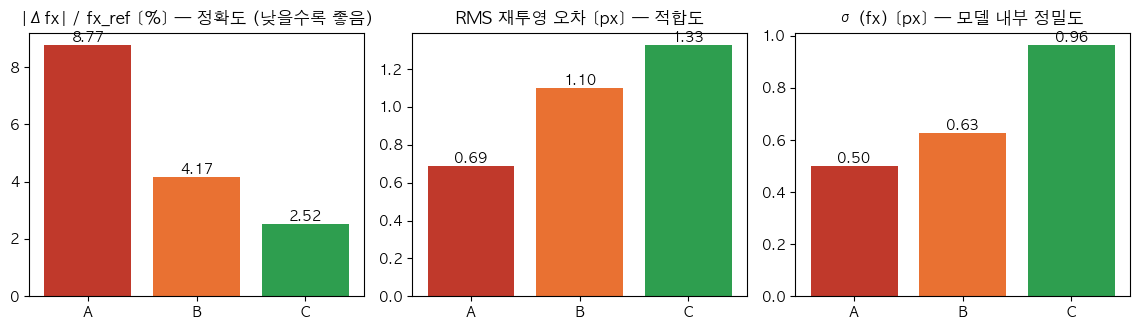

관찰: A는 RMS·σ(fx) 모두 최소인데 |Δfx|는 최대 —
      "정밀하지만 부정확" (자신 있게 틀림). 잔차·σ는 배치 퇴화로 인한 편향을 못 잡는다.


In [6]:
# ── 셀 6 · 비교 1·2: Δfx% vs RMS vs σ(fx) ──────────────────────
ks = ['A', 'B', 'C']
cols = {'A': '#C0392B', 'B': '#E97132', 'C': '#2E9E4F'}
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.4))
vals = [abs((RES[k]['K'][0, 0] - fx_ref) / fx_ref * 100) for k in ks]
axes[0].bar(ks, vals, color=[cols[k] for k in ks])
axes[0].set_title('|Δfx| / fx_ref [%] — 정확도 (낮을수록 좋음)')
axes[1].bar(ks, [RES[k]['rms'] for k in ks], color=[cols[k] for k in ks])
axes[1].set_title('RMS 재투영 오차 [px] — 적합도')
axes[2].bar(ks, [RES[k]['sigma']['fx'] for k in ks], color=[cols[k] for k in ks])
axes[2].set_title('σ(fx) [px] — 모델 내부 정밀도')
for ax, v in zip(axes, [vals, [RES[k]['rms'] for k in ks], [RES[k]['sigma']['fx'] for k in ks]]):
    for i, y in enumerate(v):
        ax.text(i, y, f'{y:.2f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout(); plt.savefig(OUT / 'cmp_fx_rms_sigma.png', dpi=130); plt.show()
print('관찰: A는 RMS·σ(fx) 모두 최소인데 |Δfx|는 최대 —')
print('      "정밀하지만 부정확" (자신 있게 틀림). 잔차·σ는 배치 퇴화로 인한 편향을 못 잡는다.')

> **가설 1 판정** — 세트 A: RMS 최저 ✅, fx 편차 최대 ✅ → 채택.
> 뜻밖의 관찰: σ(fx)까지 최소입니다. σ는 "그 배치가 만든 목적함수 골짜기의 폭"일 뿐,
> 골짜기가 **엉뚱한 곳에 파였는지**(편향)는 알려주지 않습니다. → 외부 기준(참조·커버리지 점검)이 필요한 이유.

### 비교 3 — 커버리지 맵과 σ(k₃), σ(k₄)

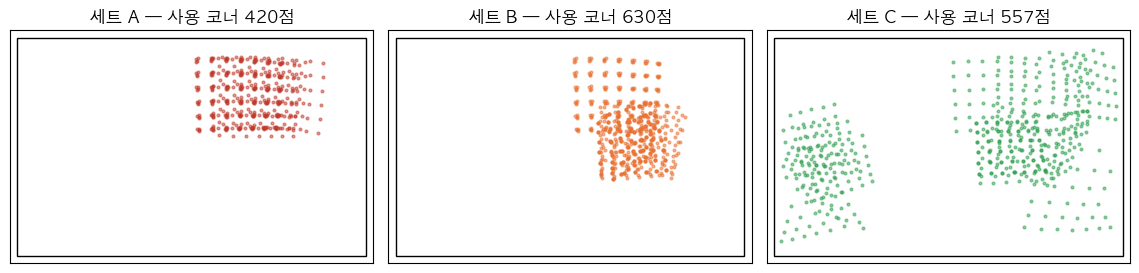

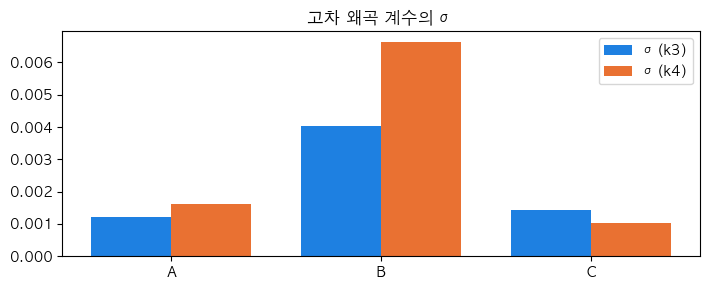

B의 계수 자체도 폭주: k3=+2.00, k4=-1.93  (참조 k3=-0.10, k4=+0.04)
A의 맵은 멀쩡해 보임 — 커버리지 맵만으로는 A를 못 잡는다 (진단 도구의 사각지대).


In [7]:
# ── 셀 7 · 비교 3: 커버리지 맵 + 고차 왜곡 σ ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.2))
for ax, k in zip(axes, ks):
    _, ids_l, pts_l = DETS[RES[k]['set']]
    P = []
    for ids, pts in zip(ids_l, pts_l):
        m = np.ones(len(ids), bool)
        if RES[k]['central_mask']:
            m = np.linalg.norm(pts - CTR, axis=1) < RES[k]['central_mask'] * HALF_DIAG
        P.append(pts[m])
    P = np.vstack(P)
    ax.scatter(P[:, 0], P[:, 1], s=4, alpha=0.5, color=cols[k])
    ax.add_patch(plt.Rectangle((0, 0), W, H, fill=False, ec='k'))
    ax.set_xlim(-40, W + 40); ax.set_ylim(H + 40, -40); ax.set_aspect('equal')
    ax.set_title(f"세트 {k} — 사용 코너 {len(P):,}점"); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.savefig(OUT / 'coverage_maps.png', dpi=130); plt.show()

fig, ax = plt.subplots(figsize=(7.2, 3.0))
x = np.arange(3); w = 0.38
ax.bar(x - w/2, [RES[k]['sigma']['k3'] for k in ks], w, label='σ(k3)', color='#1E80E1')
ax.bar(x + w/2, [RES[k]['sigma']['k4'] for k in ks], w, label='σ(k4)', color='#E97132')
ax.set_xticks(x); ax.set_xticklabels(ks); ax.legend(); ax.set_title('고차 왜곡 계수의 σ')
plt.tight_layout(); plt.savefig(OUT / 'sigma_k.png', dpi=130); plt.show()
print(f"B의 계수 자체도 폭주: k3={RES['B']['D'][2]:+.2f}, k4={RES['B']['D'][3]:+.2f}"
      f"  (참조 k3={REF['D'][2]:+.2f}, k4={REF['D'][3]:+.2f})")
print("A의 맵은 멀쩡해 보임 — 커버리지 맵만으로는 A를 못 잡는다 (진단 도구의 사각지대).")

> **가설 2 판정** — 세트 B: 가장자리 데이터 공백 → σ(k₃), σ(k₄) 수 배 ↑ **+ 계수 자체가 ±2로 폭주** ✅.
> 데이터 없는 반경 구간에서 다항식이 무엇을 하든 잔차는 모릅니다. 그 대가는 비교 4에서 눈으로.

### 비교 3-b — extrinsic 시각화: 촬영 배치를 3D로 되짚는다

커버리지 맵은 **영상 평면(2D)** 만 봅니다. 그래서 세트 A를 통과시켰습니다 — A도 화면은 골고루 덮으니까요.
빠진 정보는 **3D 자세**이고, 그건 이미 계산돼 있습니다. 캘리브레이션이 내부 파라미터와 함께 뱉은
뷰별 외부 파라미터 `rvec`/`tvec`을 그대로 그리면 됩니다.

- **Figure 1 · 카메라 고정** — 카메라 좌표계를 원점에 두고, 각 영상의 보드 코너 42점과 그 평면을 배치합니다.
  $X_c = R_j X_b + t_j$. 보드가 **어떤 거리·어떤 기울기**로 관측됐는지가 그대로 보입니다.
- **Figure 2 · 보드 고정** — R/T를 **역으로** 적용해 ($C_j = -R_j^\top t_j$) 보드를 원점에 두고 카메라를 배치합니다.
  촬영자가 실제로 어떻게 움직였는지의 재구성 — 자세 다양성을 한눈에 판정하는 뷰입니다.

두 지표도 함께 출력합니다: **거리 Z**(보드 중심까지, 보드폭 단위)와 **기울기**(광축과 보드 법선 사이 각,
0°면 완전 정면). 길이는 보드 폭을 1로 정규화했습니다 — `board.json`의 `square_size`는 실측이 아니라
비율만 의미하므로 절대 길이는 뜻이 없습니다.

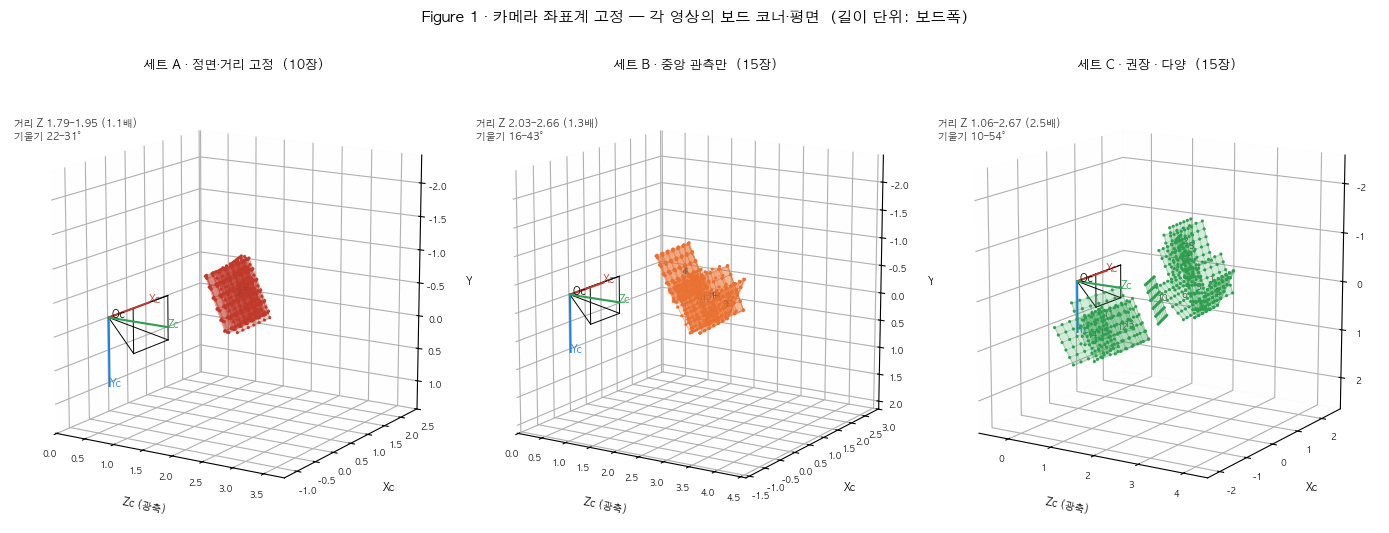

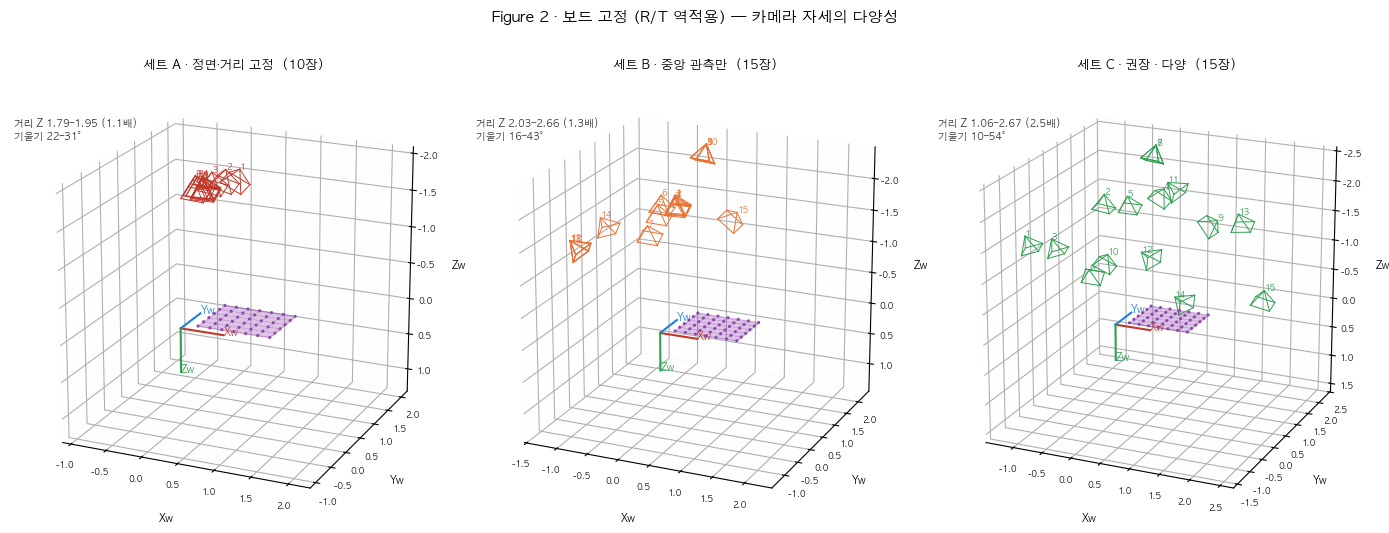

세트     장수      Z 중앙값            Z 범위     Z 변동폭      기울기 중앙         기울기 범위
A      10       1.92       1.79–1.95      1.1배         24°         22–31°
B      15       2.22       2.03–2.66      1.3배         25°         16–43°
C      15       1.91       1.06–2.67      2.5배         26°         10–54°

관찰: A는 카메라가 한 덩어리 — 거리 변동 1.1배. f와 Z를 분리해 줄 관측이 데이터에 없다 (f–Z 모호성의 실체).
      C는 거리 2.5배·기울기 10–54°로 퍼져 있다. 커버리지 맵(2D)이 놓친 A를 extrinsic(3D)은 즉시 잡는다.


In [8]:
# ── 셀 7-b · 비교 3-b: extrinsic 3D 시각화 ──────────────────────
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

GRID = (binfo['squares_y'] - 1, binfo['squares_x'] - 1)   # 내부 코너 격자 (6행, 7열)
BW   = float(np.ptp(OBJ[:, 0]))                           # 보드 폭 → 모든 길이를 '보드폭 1' 단위로

def board_in_cam(rvec, tvec):
    """X_c = R·X_b + t → 보드 42코너를 카메라 좌표계 격자 (6, 7, 3) 로"""
    R, _ = cv2.Rodrigues(rvec)
    return ((OBJ @ R.T + np.asarray(tvec).ravel()) / BW).reshape(*GRID, 3)

def cam_in_board(rvec, tvec):
    """R/T 역적용 → 보드 좌표계에서의 카메라 중심 C = -Rᵀt 와 카메라→보드 회전 Rᵀ"""
    R, _ = cv2.Rodrigues(rvec)
    return (-R.T @ np.asarray(tvec).ravel()) / BW, R.T

def pose_stats(k):
    """뷰별 (보드 중심 거리 Z, 기울기) — 기울기 = 광축과 보드 법선 사이 각. 0°면 정면(fronto-parallel)"""
    r = RES[k]; Z, T = [], []
    for j in range(r['n_img']):
        R, _ = cv2.Rodrigues(r['rvecs'][j]); t = np.asarray(r['tvecs'][j]).ravel()
        Z.append(float((R @ OBJ.mean(0) + t)[2]) / BW)
        T.append(math.degrees(math.acos(min(1.0, abs(float(R[2, 2]))))))
    return np.array(Z), np.array(T)

# 표시 축 순서를 (깊이, 가로, 세로)로 바꿔 그림이 눈에 익게 만든다
def _xyz(P, o):
    P = np.asarray(P, float).reshape(-1, 3)[:, o]; return P[:, 0], P[:, 1], P[:, 2]
def _pt(P, o):
    return [float(v[0]) for v in _xyz(P, o)]

def draw_board(ax, M, c, o, alpha=0.20):
    """보드 = 반투명 평면 + 격자선 + 코너 42점"""
    quad = np.array([M[0, 0], M[0, -1], M[-1, -1], M[-1, 0]])
    ax.add_collection3d(Poly3DCollection([np.stack(_xyz(quad, o), 1)],
                                         facecolor=c, alpha=alpha, edgecolor=c, lw=0.8))
    for i in range(M.shape[0]): ax.plot(*_xyz(M[i, :], o), color=c, lw=0.3, alpha=0.55)
    for i in range(M.shape[1]): ax.plot(*_xyz(M[:, i], o), color=c, lw=0.3, alpha=0.55)
    ax.scatter(*_xyz(M, o), s=1.6, color=c, alpha=0.95)

def draw_cam(ax, C, Rcb, s, c, o):
    """카메라 = 사각뿔 (뿔 축이 광축 +Zc 방향)"""
    q = np.array([[-.6, -.45, 1], [.6, -.45, 1], [.6, .45, 1], [-.6, .45, 1]]) * s
    Q = q @ Rcb.T + np.asarray(C).ravel()
    for i in range(4):
        ax.plot(*_xyz(np.array([C, Q[i]]), o), color=c, lw=0.7)
        ax.plot(*_xyz(np.array([Q[i], Q[(i + 1) % 4]]), o), color=c, lw=0.7)

def draw_axes(ax, C, R, s, o, names):
    for a, (nm, cc) in enumerate(zip(names, ('#C0392B', '#1E80E1', '#2E9E4F'))):
        e = np.asarray(C).ravel() + R[:, a] * s
        ax.plot(*_xyz(np.array([C, e]), o), color=cc, lw=1.5)
        ax.text(*_pt(np.array([e]), o), nm, fontsize=7, color=cc)

def setup3d(ax, pts, o, elev, azim):
    """등방 스케일(각도 왜곡 없음) + 카메라가 보는 '위쪽'을 화면 위로"""
    for a in (ax.xaxis, ax.yaxis, ax.zaxis): a.pane.set_alpha(0.04)
    P = np.vstack([np.asarray(p, float).reshape(-1, 3) for p in pts])[:, o]
    ctr = P.mean(0); rad = max(float(np.abs(P - ctr).max()), 1e-6) * 1.01
    ax.set_xlim(ctr[0] - rad, ctr[0] + rad); ax.set_ylim(ctr[1] - rad, ctr[1] + rad)
    ax.set_zlim(ctr[2] - rad, ctr[2] + rad)
    ax.set_box_aspect((1, 1, 1)); ax.tick_params(labelsize=6, pad=0)
    ax.invert_zaxis()                    # Yc(및 Zw)는 아래쪽이 + → 뒤집어 화면 위가 '위'
    ax.view_init(elev=elev, azim=azim)

LBL = {'A': 'A · 정면·거리 고정', 'B': 'B · 중앙 관측만', 'C': 'C · 권장 · 다양'}
def note(k):
    Z, T = pose_stats(k)
    return f'거리 Z {Z.min():.2f}–{Z.max():.2f} ({Z.max()/Z.min():.1f}배)\n기울기 {T.min():.0f}–{T.max():.0f}°'

# ── Figure 1 · 카메라 좌표계 고정 — 보드가 어디에 어떤 기울기로 놓였나 ──
ORD_C = [2, 0, 1]                                        # 표시 축 = (Zc, Xc, Yc)
fig = plt.figure(figsize=(14, 5.1))
for i, k in enumerate(ks):
    ax = fig.add_subplot(1, 3, i + 1, projection='3d'); r = RES[k]; P = [np.zeros((1, 3))]
    for j in range(r['n_img']):
        M = board_in_cam(r['rvecs'][j], r['tvecs'][j])
        draw_board(ax, M, cols[k], ORD_C); P.append(M)
        ax.text(*_pt(M.reshape(-1, 3).mean(0, keepdims=True), ORD_C), str(j + 1),
                fontsize=6, color='#333333')
    draw_cam(ax, np.zeros(3), np.eye(3), 0.75, 'k', ORD_C)
    draw_axes(ax, np.zeros(3), np.eye(3), 1.05, ORD_C, ('Xc', 'Yc', 'Zc'))
    ax.text(0, 0, 0, ' Oc', fontsize=7)
    setup3d(ax, P, ORD_C, elev=14, azim=-58)
    ax.text2D(0.01, 0.86, note(k), transform=ax.transAxes, fontsize=7, color='#333333')
    ax.set_xlabel('Zc (광축)', fontsize=7); ax.set_ylabel('Xc', fontsize=7); ax.set_zlabel('Yc', fontsize=7)
    ax.set_title(f'세트 {LBL[k]}  ({r["n_img"]}장)', fontsize=9)
fig.suptitle('Figure 1 · 카메라 좌표계 고정 — 각 영상의 보드 코너·평면  (길이 단위: 보드폭)', fontsize=11, y=1.04)
plt.tight_layout(); plt.savefig(OUT / 'extrinsics_camera_frame.png', dpi=130, bbox_inches='tight'); plt.show()

# ── Figure 2 · 보드 고정 (R/T 역적용) — 촬영자가 실제로 얼마나 움직였나 ──
ORD_W = [0, 1, 2]                                        # 표시 축 = (Xw, Yw, Zw)
fig = plt.figure(figsize=(14, 5.1))
for i, k in enumerate(ks):
    ax = fig.add_subplot(1, 3, i + 1, projection='3d'); r = RES[k]
    M0 = (OBJ / BW).reshape(*GRID, 3)
    draw_board(ax, M0, '#8E44AD', ORD_W, alpha=0.30); P = [M0]
    draw_axes(ax, np.zeros(3), np.eye(3), 0.6, ORD_W, ('Xw', 'Yw', 'Zw'))
    for j in range(r['n_img']):
        C, Rcb = cam_in_board(r['rvecs'][j], r['tvecs'][j])
        draw_cam(ax, C, Rcb, 0.26, cols[k], ORD_W)
        ax.text(*_pt(np.array([C]), ORD_W), str(j + 1), fontsize=6, color=cols[k]); P.append(C)
    setup3d(ax, P, ORD_W, elev=20, azim=-66)
    ax.text2D(0.01, 0.86, note(k), transform=ax.transAxes, fontsize=7, color='#333333')
    ax.set_xlabel('Xw', fontsize=7); ax.set_ylabel('Yw', fontsize=7); ax.set_zlabel('Zw', fontsize=7)
    ax.set_title(f'세트 {LBL[k]}  ({r["n_img"]}장)', fontsize=9)
fig.suptitle('Figure 2 · 보드 고정 (R/T 역적용) — 카메라 자세의 다양성', fontsize=11, y=1.04)
plt.tight_layout(); plt.savefig(OUT / 'extrinsics_board_frame.png', dpi=130, bbox_inches='tight'); plt.show()

print(f"{'세트':<4}{'장수':>5}{'Z 중앙값':>11}{'Z 범위':>16}{'Z 변동폭':>10}{'기울기 중앙':>12}{'기울기 범위':>15}")
for k in ks:
    Z, T = pose_stats(k)
    print(f'{k:<4}{RES[k]["n_img"]:>5}{np.median(Z):>11.2f}{f"{Z.min():.2f}–{Z.max():.2f}":>16}'
          f'{Z.max() / Z.min():>9.1f}배{np.median(T):>11.0f}°{f"{T.min():.0f}–{T.max():.0f}°":>15}')
print('\n관찰: A는 카메라가 한 덩어리 — 거리 변동 1.1배. f와 Z를 분리해 줄 관측이 데이터에 없다 (f–Z 모호성의 실체).')
print('      C는 거리 2.5배·기울기 10–54°로 퍼져 있다. 커버리지 맵(2D)이 놓친 A를 extrinsic(3D)은 즉시 잡는다.')

> **가설 1의 정체가 드러나는 그림** — Figure 2의 세트 A: 카메라 10대가 **한 덩어리**입니다.
> 거리 변동 1.1배, 기울기 22–31°. 삼각대를 세워 두고 보드만 살짝 흔들며 찍은 배치입니다.
> C는 거리 2.5배·기울기 10–54°로 퍼져 있습니다.
>
> 셀 6에서 A의 fx가 −8.8% 틀린 이유가 여기 있습니다 — **초점거리와 거리(f–Z)를 분리해 줄
> 거리 다양성이 데이터에 아예 없었다.** 잔차는 이 결핍을 모르고(RMS 최소), σ도 모릅니다(σ 최소).
> 커버리지 맵(2D)도 통과시켰습니다. **extrinsic 배치(3D)만이 즉시 잡아냅니다** — 진단은 함께 봐야 합니다.

### 비교 4 — 가장자리에서 드러나는 진실

전 세트를 **같은 목적지 카메라(newK)** 로 언디스토션한 뒤, 동일한 모서리 영역을 잘라 비교합니다.

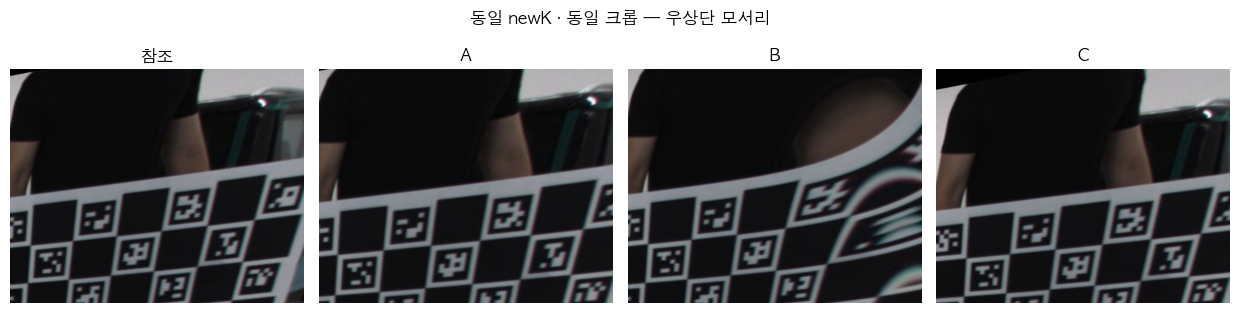

In [9]:
# ── 셀 8 · 비교 4: 가장자리 크롭 ────────────────────────────────
K_ref = np.array(REF['K']); D_ref = np.array(REF['D']).reshape(4, 1)
newK = cv2.fisheye.estimateNewCameraMatrixForUndistortRectify(
    K_ref, D_ref, (W, H), np.eye(3), balance=0.3)
test_img = cv2.imread(str(sorted((DATA / 'master').glob('*.jpg'))[0]))
CROP = (slice(0, 430), slice(1380, 1920))          # 우상단 모서리

def undistort_with(Kx, Dx):
    m1, m2 = cv2.fisheye.initUndistortRectifyMap(
        np.array(Kx), np.array(Dx).reshape(4, 1), np.eye(3), newK, (W, H), cv2.CV_16SC2)
    return cv2.remap(test_img, m1, m2, cv2.INTER_LINEAR)

panels = [('참조', K_ref, D_ref)] + [(k, RES[k]['K'], RES[k]['D']) for k in ks]
fig, axes = plt.subplots(1, 4, figsize=(12.5, 3.1))
for ax, (nm, Kx, Dx) in zip(axes, panels):
    ax.imshow(cv2.cvtColor(undistort_with(Kx, Dx)[CROP], cv2.COLOR_BGR2RGB))
    ax.set_title(nm); ax.axis('off')
plt.suptitle('동일 newK · 동일 크롭 — 우상단 모서리', y=1.02)
plt.tight_layout(); plt.savefig(OUT / 'edge_crops.png', dpi=130, bbox_inches='tight'); plt.show()

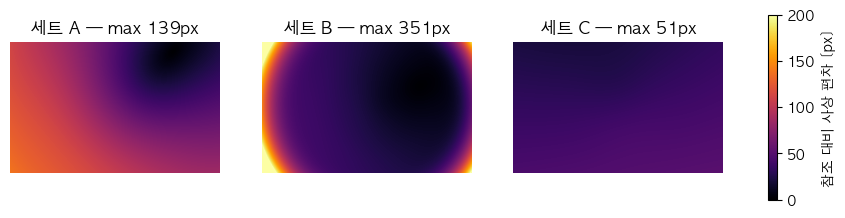

B: 중앙은 작고 가장자리에서 폭발(외삽) · A: 전역 균일하게 큼(스케일 편향) · C: 전역 작음


In [10]:
# ── 셀 9 · (보너스) 정답 자막: 워핑 사상의 편차 지도 ─────────────
# 각 세트의 언디스토션 맵이 참조 맵과 몇 px 어긋나는지 — "가장자리 붕괴"의 정량판
def umap(Kx, Dx):
    mx, my = cv2.fisheye.initUndistortRectifyMap(
        np.array(Kx), np.array(Dx).reshape(4, 1), np.eye(3), newK, (W, H), cv2.CV_32F)
    return np.dstack([mx, my])
m0 = umap(K_ref, D_ref)
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.0))
for ax, k in zip(axes, ks):
    dev = np.linalg.norm(umap(RES[k]['K'], RES[k]['D']) - m0, axis=-1)
    im = ax.imshow(dev, cmap='inferno', vmin=0, vmax=200)
    ax.set_title(f"세트 {k} — max {dev.max():.0f}px"); ax.axis('off')
fig.colorbar(im, ax=axes, shrink=0.8, label='참조 대비 사상 편차 [px]')
plt.savefig(OUT / 'map_deviation.png', dpi=130, bbox_inches='tight'); plt.show()
print('B: 중앙은 작고 가장자리에서 폭발(외삽) · A: 전역 균일하게 큼(스케일 편향) · C: 전역 작음')

### 질문

- **Q1.** A의 RMS가 가장 낮은 이유를 자신의 언어로 — "모호성" 단어 금지 버전으로도 설명해 보세요.
- **Q2.** 현장에서 세트 A류 실수가 나오기 쉬운 상황은? (예: 삼각대 고정 반복 촬영)
- **Q3.** σ(fx)가 가장 작은 A가 fx는 가장 틀렸습니다 — σ는 무엇을 재고, 무엇을 못 재나요?


---
## Part 4 · 워핑 원리 데모 — 언디스토션도 워핑이다

방금 쓴 `remap`의 내부가 **역방향 워핑**입니다. 순방향으로 짜면 무슨 일이 생기는지 직접 확인합니다.

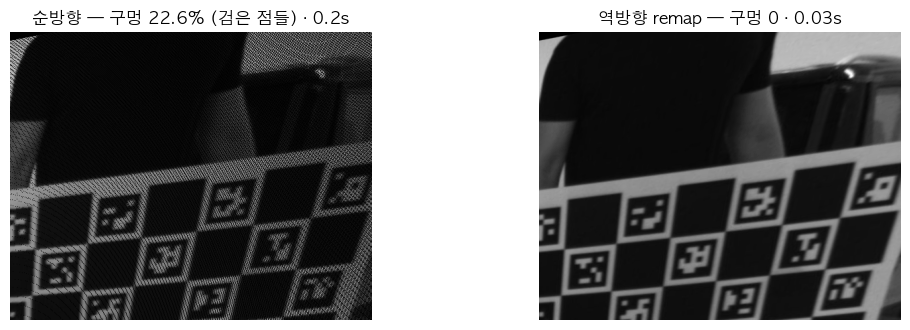

사상이 늘어나는 가장자리일수록 구멍 밀도↑ — 내일 파노라마·모레 BEV 워핑 전부 역방향이 표준.


In [11]:
# ── 셀 10 · 순방향 vs 역방향 ────────────────────────────────────
gray = cv2.cvtColor(test_img, cv2.COLOR_BGR2GRAY)

# (a) 순방향: 원본 픽셀을 목적지로 '밀기'
t0 = time.time()
ys, xs = np.mgrid[0:H, 0:W]
src = np.stack([xs, ys], -1).reshape(-1, 1, 2).astype(np.float64)
dst = cv2.fisheye.undistortPoints(src, K_ref, D_ref, P=newK).reshape(-1, 2)
xi, yi = np.round(dst[:, 0]).astype(int), np.round(dst[:, 1]).astype(int)
ok = (xi >= 0) & (xi < W) & (yi >= 0) & (yi < H)
fwd = np.zeros((H, W), np.uint8); hit = np.zeros((H, W), np.uint16)
fwd[yi[ok], xi[ok]] = gray.reshape(-1)[ok]
np.add.at(hit, (yi[ok], xi[ok]), 1)
t_fwd = time.time() - t0

# (b) 역방향: cv2.remap (= 목적지 픽셀마다 원본을 역조회 + 보간)
t0 = time.time()
m1, m2 = cv2.fisheye.initUndistortRectifyMap(K_ref, D_ref, np.eye(3), newK, (W, H), cv2.CV_16SC2)
bwd = cv2.remap(gray, m1, m2, cv2.INTER_LINEAR)
t_bwd = time.time() - t0

covered = hit > 0
holes = (~covered) & (bwd > 0)          # 역방향이 채우는 영역 기준의 구멍
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.4))
axes[0].imshow(fwd[CROP], cmap='gray'); axes[0].set_title(
    f'순방향 — 구멍 {holes.mean()*100:.1f}% (검은 점들) · {t_fwd:.1f}s')
axes[1].imshow(bwd[CROP], cmap='gray'); axes[1].set_title(f'역방향 remap — 구멍 0 · {t_bwd:.2f}s')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.savefig(OUT / 'warp_demo.png', dpi=130); plt.show()
print('사상이 늘어나는 가장자리일수록 구멍 밀도↑ — 내일 파노라마·모레 BEV 워핑 전부 역방향이 표준.')

---
## 랩업 — 오늘의 결론

1. **촬영 배치가 JᵀJ를 설계한다** — 배치 실수는 코드로 못 고친다
2. **RMS는 적합도일 뿐** — A는 RMS·σ 최소인데 fx 최악: *정밀하지만 부정확*
3. σ의 한계 — 분산은 재지만 **편향은 못 잡는다** → 참조·커버리지·가장자리와 함께 판정
4. 자세·거리 **다양성**이 f·주점을, **전체 커버**가 왜곡 고차항을 관측 가능하게 한다
5. 워핑은 **역방향**이 표준

In [12]:
# ── 셀 11 · 결과 저장 ───────────────────────────────────────────
summary = {k: dict(n_img=int(RES[k]['n_img']), rms=float(RES[k]['rms']),
                   K=RES[k]['K'].tolist(), D=RES[k]['D'].tolist(),
                   sigma={a: float(b) for a, b in RES[k]['sigma'].items()})
           for k in RES}
summary['reference'] = dict(rms=REF['rms_px'], K=REF['K'], D=REF['D'])
json.dump(summary, open(OUT / 'results.json', 'w'), indent=2)
print('저장 완료 →', sorted(p.name for p in OUT.iterdir()))

저장 완료 → ['cmp_fx_rms_sigma.png', 'coverage_maps.png', 'edge_crops.png', 'extrinsics_board_frame.png', 'extrinsics_camera_frame.png', 'map_deviation.png', 'record_sheet.csv', 'results.json', 'sigma_k.png', 'warp_demo.png']
